# Unsupervised Learning Predict Student Solution

© Explore Data Science Academy

### Honour Code
We Team-BM3, confirm - by submitting this document - that the solutions in this notebook are a result of my own work and that I abide by the [EDSA honour code](https://drive.google.com/file/d/1QDCjGZJ8-FmJE3bZdIQNwnJyQKPhHZBn/view?usp=sharing).

Non-compliance with the honour code constitutes a material breach of contract.

# Predict Overview: Movie Recommendation Challenge



## Introduction

Recommender systems are crucial from a social and economic standpoint in the technology-driven society we live in today to enable people to make informed decisions about the information they consume on a daily basis. One example is movie content suggestions, where intelligent algorithms may assist viewers identify exceptional titles among tens of thousands of possibilities.

## Problem

We are challenged to build a recommendation algorithm based on content or collaborative filtering that is capable of accurately predicting how a user will rate a movie they have not yet seen based on their historical preferences in order for users to make informed decisions about the information they consume on a daily basis.

## Aim and Objectives

The potential for economic gain is enormous because users of the system would be exposed to content they would wish to read or buy, driving sales and platform affinity.

Team BM3 is tasked with developing a collaborative filtering or content-based recommendation algorithm that can precisely predict how a user would rate a film they haven't yet seen based on their past preferences.


In order to achieve the aim for this challenge, we have the following objectives:

- Analyse the supplied data;
- Find potential data problems and clean the dataset;
- Determine if all features are significant, and potentially get rid of less significant features;
- Build a model that is capable of predicting how a user would rate a movie;
- Evaluate the performance of the developed models;
- Explain the inner working of the models and how their performance was analysed.

## Data Overview

### Data Description
The dataset includes millions of 5-star ratings from MovieLens users. Industry and academic researchers have long used the MovieLens dataset to improve the performance of explicitly-based recommender systems.

### Source
The GroupLens research team in the Department of Computer Science and Engineering at the University of Minnesota maintains the data for the MovieLens dataset. Additional movie content data was obtained lawfully from [IMDB](https://www.imdb.com/)

### Flies provided
- `genome_scores.csv` - a score mapping the strength between movies and tag-related properties.
- `genome_tags.csv` - user assigned tags for genome-related scores.
- `imdb_data.csv` - Additional movie metadata scraped from IMDB using the links.csv file.
- `links.csv` - File providing a mapping between a MovieLens ID and associated IMDB and TMDB IDs.
- `sample_submission.csv` - Sample of the submission format for the hackathon.
- `tags.csv` - User assigned for the movies within the dataset.
- `test.csv` - The test split of the dataset. Contains user and movie IDs with no rating data.
- `train.csv` - The training split of the dataset. Contains user and movie IDs with associated rating data.

## Team Members
- Maggie Kalembo
- Opuere Ponuwei
- Amaechi Ngwoke
- Mukhtar Abebefe
- Chikezie Ezenna

<a id="cont"></a>

## Table of Contents

<a href=#1>1. Comet Setup</a>

<a href=#2>2. Importing Packages</a>

<a href=#3>3. Loading Data</a>

<a href=#4>4. Exploratory Data Analysis (EDA)</a>

<a href=#5>5. Feature Engineering</a>

<a href=#6>6. Modelling</a>

<a href=#7>7. Model Evaluation</a>

<a href=#8>8. Model Explanation</a>

<a href=#9>9. Conclusion</a>

<a href=#10>10. Making Kaggle Submission</a>

<a href=#11>11. Pickle Files for Streamlit</a>

<a href=#12>12. Log Model Features To Comet_ml</a>

<a href=#13>13. References</a>

<a id="1"></a>
## 1. Comet Setup
<a href=#cont>Back to Table of Contents</a>



<a id="2"></a>
## 2. Importing Packages
<a href=#cont>Back to Table of Contents</a>

In [2]:
# data analysis and wrangling libraries
import numpy as np
import pandas as pd

# visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
from collections import Counter

from wordcloud import WordCloud, STOPWORDS
from scipy import stats

# modelling
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from surprise import Reader, Dataset
from surprise.model_selection import cross_validate
from surprise import NormalPredictor
from surprise import KNNBasic
from surprise import KNNWithMeans
from surprise import KNNWithZScore
from surprise import KNNBaseline
from surprise import SVD
from surprise import BaselineOnly
from surprise import SVDpp
from surprise import NMF
from surprise import SlopeOne
from surprise import CoClustering
from surprise.accuracy import rmse
from surprise import accuracy





# Imported for our sanity
import warnings
warnings.filterwarnings('ignore')



ModuleNotFoundError: No module named 'surprise'

In [3]:
!pip install scikit-surprise

  Using cached scikit-surprise-1.1.3.tar.gz (771 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py clean for scikit-surprise
Failed to build scikit-surprise
  Running setup.py install for scikit-surprise: started
  Running setup.py install for scikit-surprise: finished with status 'error'


  error: subprocess-exited-with-error
  
  python setup.py bdist_wheel did not run successfully.
  exit code: 1
  
  [101 lines of output]
  C:\Users\alvar\AppData\Local\Temp\pip-install-jh1qxoni\scikit-surprise_d0fb4dfa7bc44b3c906d9fa7f7974e78\setup.py:65: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
  !!
  
          ********************************************************************************
          Requirements should be satisfied by a PEP 517 installer.
          If you are using pip, you can try `pip install --use-pep517`.
          ********************************************************************************
  
  !!
    dist.Distribution().fetch_build_eggs(["numpy>=1.17.3"])
  running bdist_wheel
  running build
  running build_py
  creating build
  creating build\lib.win-amd64-cpython-310
  creating build\lib.win-amd64-cpython-310\surprise
  copying surprise\accuracy.py -> build\lib.win-amd64-cpython-310\surprise
  copying surprise\bu

<a id="3"></a>
## 3. Loading Data
<a href=#cont>Back to Table of Contents</a>

In [3]:
# load the data
genome_scores = pd.read_csv(r'C:\Users\alvar\Documents\Data Science\Unsupervised learning\Predict\genome_scores.csv')
genome_tags = pd.read_csv(r'C:\Users\alvar\Documents\Data Science\Unsupervised learning\Predict\genome_tags.csv')
imdb_df = pd.read_csv(r'C:\Users\alvar\Documents\Data Science\Unsupervised learning\Predict\imdb_data.csv')
links = pd.read_csv(r'C:\Users\alvar\Documents\Data Science\Unsupervised learning\Predict\links.csv')
movies= pd.read_csv(r'C:\Users\alvar\Documents\Data Science\Unsupervised learning\Predict\movies.csv')
tags = pd.read_csv(r'C:\Users\alvar\Documents\Data Science\Unsupervised learning\Predict\tags.csv')
df_test = pd.read_csv(r'C:\Users\alvar\Documents\Data Science\Unsupervised learning\Predict\test.csv')
df_rating = pd.read_csv(r'C:\Users\alvar\Documents\Data Science\Unsupervised learning\Predict\train.csv')

<a id="4"></a>
## 4. Exploratory Data Analysis (EDA)
<a href=#cont>Back to Table of Contents</a>

##### Genome Scores

The **genome scores** are numerical ratings or weights assigned to specific attributes or characteristics of a movie. These scores represent the importance or relevance of each attribute in determining the overall profile of a film. By analyzing the genome scores of different movies, the recommendation system can identify patterns and similarities between films and make personalized recommendations based on a user's preferences.

In [5]:
genome_scores.head()

,movieId,tagId,relevance
0,1,1,0.02875
1,1,2,0.02375
2,1,3,0.06250
3,1,4,0.07575
4,1,5,0.14075


In [6]:
genome_scores.shape

(15584448, 3)

##### Genome Tags

In [7]:
genome_tags.head()

,tagId,tag
0,1,007
1,2,007 (series)
2,3,18th century
3,4,1920s
4,5,1930s


In [8]:
genome_tags.shape

(1128, 2)

##### IMBD data

**Imdb** means the Internet Movie database. It is an onliine database with information and statistics about movies. This database contains interesting properties of movies such as title cast, director, runtime, budget and plot keywords. 

In [9]:
imdb_df.head()

,movieId,title_cast,director,runtime,budget,plot_keywords
0,1,Tom Hanks|Tim Allen|Don Rickles|Jim Varney|Wal...,John Lasseter,81.0,"$30,000,000",toy|rivalry|cowboy|cgi animation
1,2,Robin Williams|Jonathan Hyde|Kirsten Dunst|Bra...,Jonathan Hensleigh,104.0,"$65,000,000",board game|adventurer|fight|game
2,3,Walter Matthau|Jack Lemmon|Sophia Loren|Ann-Ma...,Mark Steven Johnson,101.0,"$25,000,000",boat|lake|neighbor|rivalry
3,4,Whitney Houston|Angela Bassett|Loretta Devine|...,Terry McMillan,124.0,"$16,000,000",black american|husband wife relationship|betra...
4,5,Steve Martin|Diane Keaton|Martin Short|Kimberl...,Albert Hackett,106.0,"$30,000,000",fatherhood|doberman|dog|mansion


In [10]:
imdb_df.shape

(27278, 6)

The properties of interest from the imdb database are title_cast, director, runtime, plot_keywords.

In [11]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [12]:
links.columns

Index(['movieId', 'imdbId', 'tmdbId'], dtype='object')

* `movieId`: It's serial number for movie
* `imdbId`: Movie id given on IMDb platform
* `tmdbId`: Movie id given on TMDb platform

##### MOVIE TAGS

A **movie tag**, is a short phrase or sentence that is used to capture the essence or highlight a key aspect of a film. It is typically displayed in promotional materials, movie posters, trailers, and advertising campaigns to generate interest and intrigue potential viewers. Movie tags aim to pique the audience's curiosity, create anticipation, and convey the theme, genre, or unique selling point of the movie.

In [13]:
tags.head()

,userId,movieId,tag,timestamp
0,3,260,classic,1439472355
1,3,260,sci-fi,1439472256
2,4,1732,dark comedy,1573943598
3,4,1732,great dialogue,1573943604
4,4,7569,so bad it's good,1573943455


Based on the information provided above, it is evident that a user can assign multiple tags to a single movie. Now, let's investigate whether multiple users can tag the same movie.

In [14]:
# searching for user tags for movie id 1
tags[tags['movieId'] == 1]

,userId,movieId,tag,timestamp
2306,791,1,Owned,1515175493
3749,1048,1,imdb top 250,1172144394
4226,1361,1,Pixar,1216146311
10003,3164,1,Pixar,1223304727
10004,3164,1,time travel,1223304729
...,...,...,...,...
1084685,160835,1,American Animation,1437092829
1084688,160858,1,computer animation,1451035426
1084689,160858,1,pixar,1451035426
1088052,161172,1,Pixar,1159534063


In [15]:
tags.shape

(1093360, 4)

From the above, we can also see that several users can tag the same movie. 

In [16]:
movies['tag'] = movies.merge(tags, on=['movieId'], how='left')['tag']


In [17]:
movies.sample(10)

,movieId,title,genres,tag
43916,167104,Tamo Junto (2016),Comedy,bittersweet
5036,5142,"Firemen's Ball, The (Horí, má panenko) (1967)",Comedy|Drama,story
38050,153939,Mockingbird Lane (2012),Comedy|Fantasy|Horror|Mystery,thought-provoking
10089,34238,Symmetry (Symetria) (2003),Crime|Drama,feel-good
58465,198667,Abducted in Plain Sight (2017),Documentary,animation
38255,154424,Teenage Angst (2008),Drama,twist ending
52117,184605,The Gods Must Be Funny in China (1994),Comedy,Nudity (Full Frontal - Notable)
44500,168354,Dog (2015),Drama,Good story
10610,43624,Here Comes the Groom (1951),Comedy|Musical|Romance,George Clooney
10212,36545,G (2002),Drama|Romance,great soundtrack


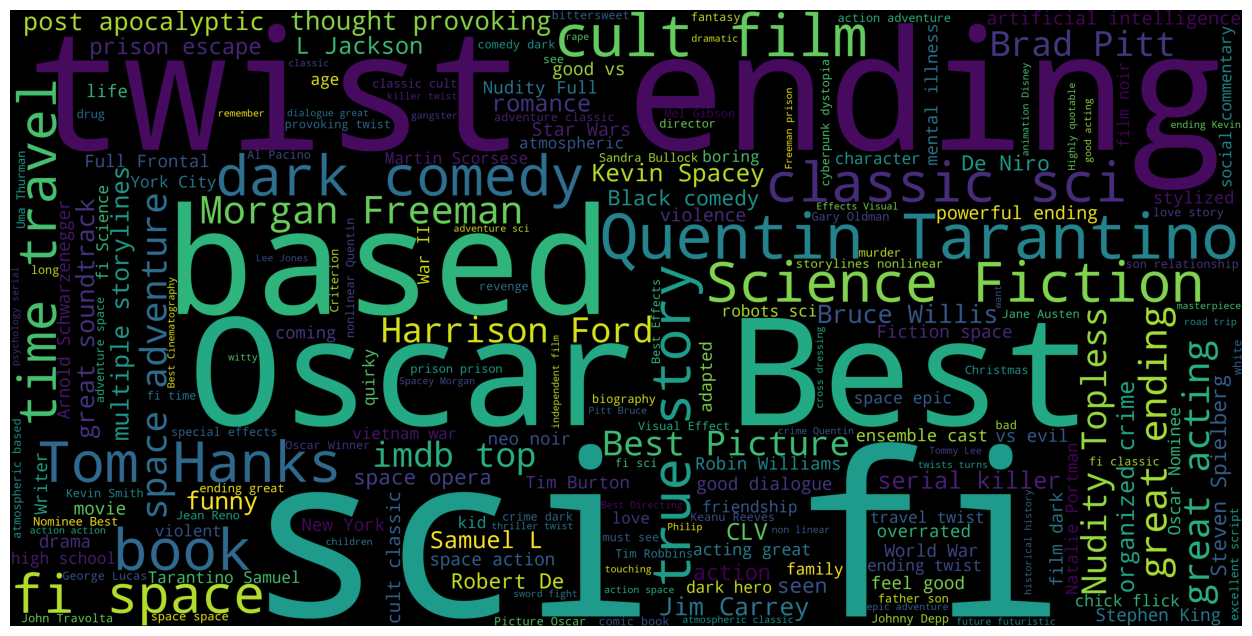

In [18]:
# Creating a wordcloud of the movie titles to view the most popular movie titles withtin the word cloud
movies['tag'] = movies['tag'].fillna("").astype('str')
tags_corpus = ' '.join(movies['tag'])
tags_wordcloud = WordCloud(stopwords=STOPWORDS, background_color='black', height=2000, width=4000, random_state= 42).generate(tags_corpus)

# Plotting the wordcloud
plt.figure(figsize=(16,8))
plt.imshow(tags_wordcloud)
plt.axis('off')
plt.show()

The wordcloud shows that people watched more tag many of the movies with words like Sci Fi, comedy, twist, nudity, Oscar best, topless, Morgan Freeman

##### Movie Ratings

In [19]:
df_rating.head()

,userId,movieId,rating,timestamp
0,5163,57669,4.0,1518349992
1,106343,5,4.5,1206238739
2,146790,5459,5.0,1076215539
3,106362,32296,2.0,1423042565
4,9041,366,3.0,833375837


In [20]:
df_rating.shape

(10000038, 4)

In [21]:
df_rating.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

* `movieId`: It's serial number for movie
* `imdbId`: Movie id given on IMDb platform
* `tmdbId`: Movie id given on TMDb platform

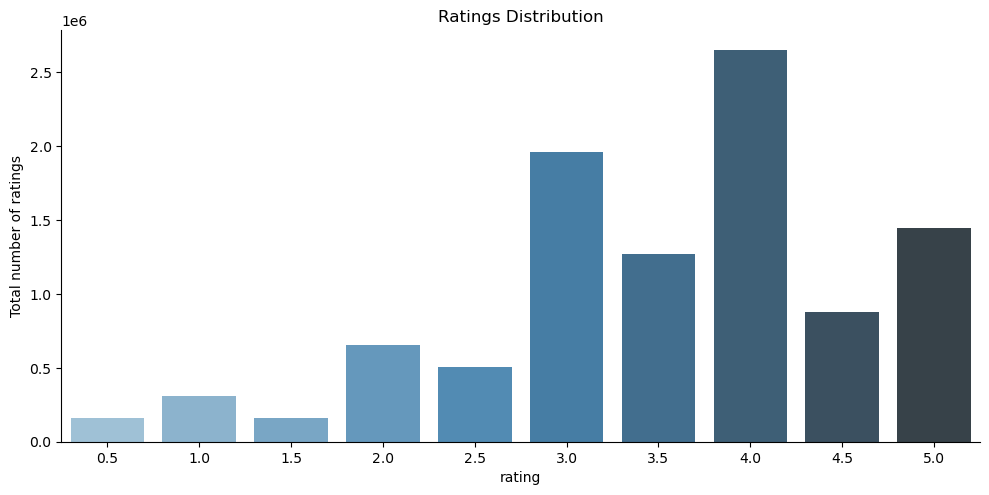

Average rating in dataset: 3.5333951730983424


In [22]:
g = sns.catplot(x="rating", data=df_rating, aspect=2.0, kind='count', palette="Blues_d")
g.set_ylabels("Total number of ratings")
plt.title("Ratings Distribution")
plt.show()
print (f'Average rating in dataset: {np.mean(df_rating["rating"])}')

In [23]:
mode = stats.mode(df_rating["rating"])
print(f'Modal rating in dataset: {mode.mode[0]}')

Modal rating in dataset: 4.0


**Observation**

* Most of the movies are rated above average. The top three most common ratings are 3.0, 4.0 and 5.0. Generally, the ratings for movies has been good as the chart skews to the left. A look at the chart, we can observe that users prefer to rate movies in integers say 3 than thier float say 3.5. For an instance 1.0 is more frequent than 1.5, 2.0 than 2.5, 3.0 than 3.5 and goes all the way.

* The most frequently occurring rate was 4.0.

In [24]:
movies.head()

,movieId,title,genres,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Owned
1,2,Jumanji (1995),Adventure|Children|Fantasy,imdb top 250
2,3,Grumpier Old Men (1995),Comedy|Romance,Pixar
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,Pixar
4,5,Father of the Bride Part II (1995),Comedy,time travel


In [25]:
movies[movies['title']=="Planet Earth II (2016)"]

,movieId,title,genres,tag
45741,171011,Planet Earth II (2016),Documentary,animation


In [26]:
# cleaning up the movie genre by removing unwanted characters
movies['genres'] = movies['genres'].str.split('|').str.join(',')

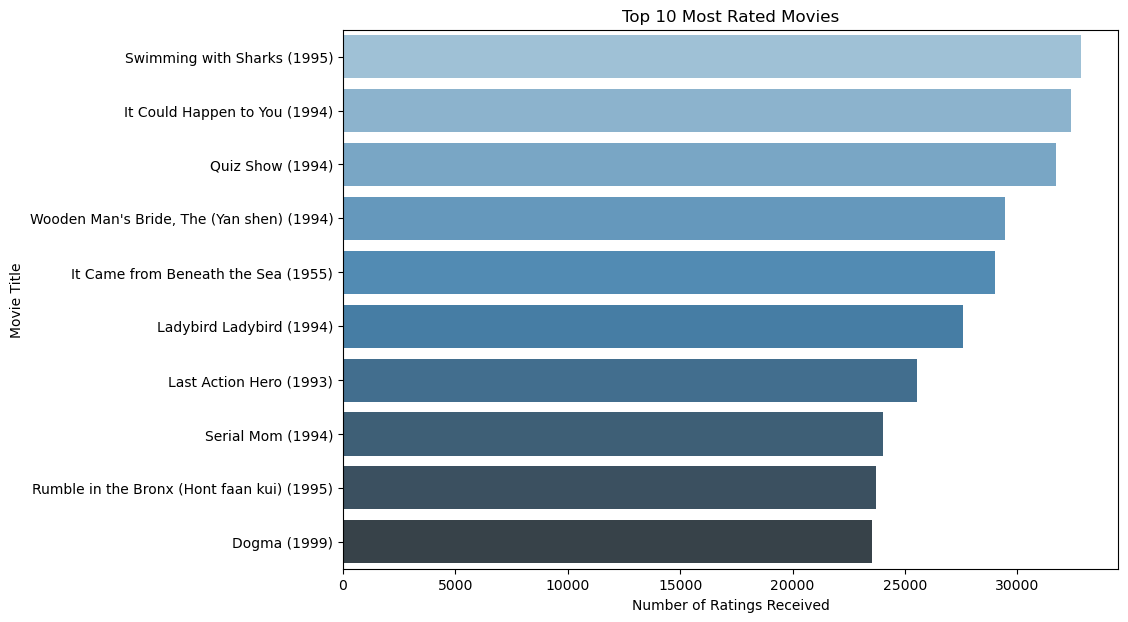

In [27]:
fig, ax = plt.subplots(figsize=(10, 7))

# Retrieve the counts of movieId and select the top 10
data = df_rating['movieId'].value_counts().sort_values(ascending=False)[:10]

# Retrieve the movie titles corresponding to the top 10 movieIds
titles = [movies.loc[movieId, 'title'] for movieId in data.index]

# Create the bar plot
sns.barplot(y=titles, x=data, ax=ax, palette="Blues_d")

# Set the title, ylabel, and xlabel
plt.title('Top 10 Most Rated Movies')
plt.ylabel("Movie Title")
plt.xlabel("Number of Ratings Received")

# Display the plot
plt.show()


* The visual displays the top 10 most rated movies, with "swimming with sharks" being the highest-rated movie, followed by "it could happen to you" However, it is important to note that the highest rating does not necessarily indicate that these are the best movies.

* The most rated movies are movies produced in the 90's. Although, these chart does not determine if the movies are positevly or negatively rated. It only shows the total number of ratings they are able to garner. 

* The question is, which movies are best rated?

##### Best Rated Movies

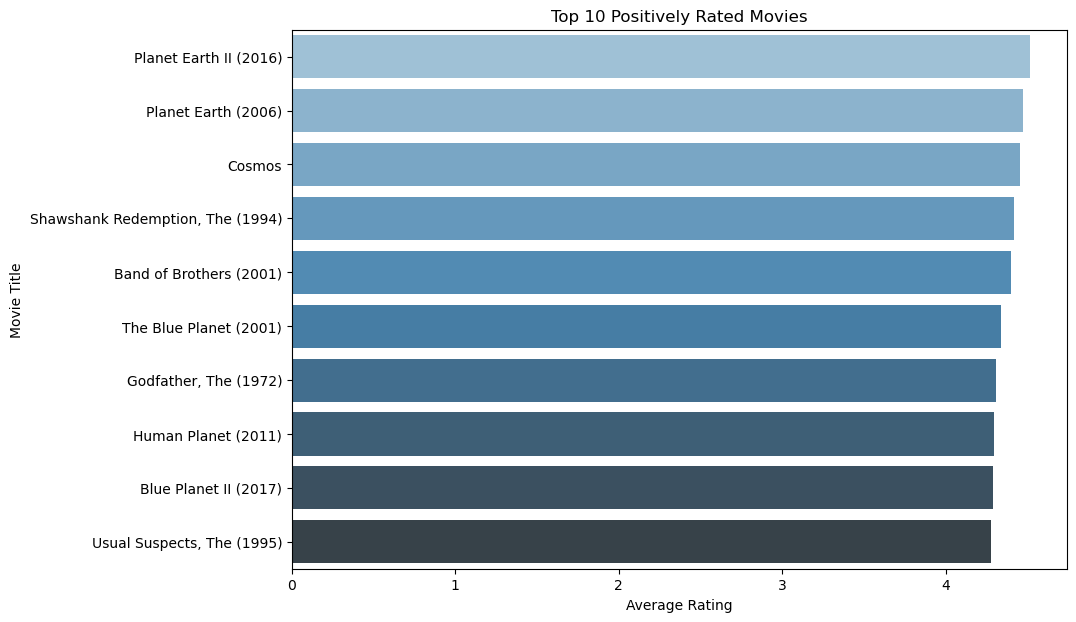

In [28]:
def most_popular(start, stop):
    # Filter out movies with less than 50 ratings
    required_movies = df_rating['movieId'].value_counts()[df_rating['movieId'].value_counts() > 50].index
    data = df_rating[df_rating['movieId'].isin(required_movies)]

    # Calculate the average rating
    data = data.groupby('movieId')['rating'].mean().sort_values(ascending=False)[start:stop]
    return data

data = most_popular(0, 10)

# Plotting the data
fig, ax = plt.subplots(figsize=(10, 7))
titles = [movies.loc[movies['movieId'] == movieId, 'title'].iloc[0] for movieId in data.index]
sns.barplot(y=titles, x=data.values, ax=ax, palette="Blues_d")
plt.title('Top 10 Positively Rated Movies')
plt.ylabel("Movie Title")
plt.xlabel("Average Rating")
plt.show()


In [29]:
movies[movies['title']=="Planet Earth II (2016)"]

,movieId,title,genres,tag
45741,171011,Planet Earth II (2016),Documentary,animation


In [30]:
movies[movies['title']=="Cosmos"]

,movieId,title,genres,tag
45973,171495,Cosmos,(no genres listed),magic


**Observation**

* The best and second best movies where parts I and II of Planet Earth (same movie). They are both documentaries. We will explore the common genres of the top rated movies.

* The movie Cosmos wasn't group into a genre, could it be there are other movies that do not have genre. I percieve problem 🙆🏼‍♂ as this will affect the content based recommeded system.

##### Genres

A **movie genre** refers to a category or classification that groups films based on their shared themes, settings, narrative structures, and stylistic elements. Genres provide a way to categorize and classify movies into distinct types or styles, allowing audiences to easily identify and select films that align with their preferences.

There are numerous movie genres, including but not limited to:

1. **Action**: Films characterized by intense physical activity, thrilling stunts, and fast-paced sequences.
2. **Comedy**: Movies intended to make the audience laugh and entertain through humor and comedic situations.
3. **Drama**: Films that focus on emotional depth, character development, and serious storytelling.
4. **Romance**: Movies centered around love, relationships, and emotional connections between characters.
5. **Science Fiction**: Films that explore imaginative concepts, futuristic settings, and scientific advancements.
6. **Horror**: Movies designed to elicit fear, suspense, and shock through elements of suspense, supernatural phenomena, or psychological terror.
7. **Thriller**: Suspenseful films that keep the audience on the edge of their seats through tension, plot twists, and intense storytelling.
8. **Fantasy**: Movies set in imaginary worlds, often involving magic, mythical creatures, and epic adventures.
9. **Adventure**: Films that follow characters on exciting journeys and quests, typically involving exploration, action, and challenges.
10. **Animation**: Movies created through the technique of animating drawings, objects, or computer-generated images.


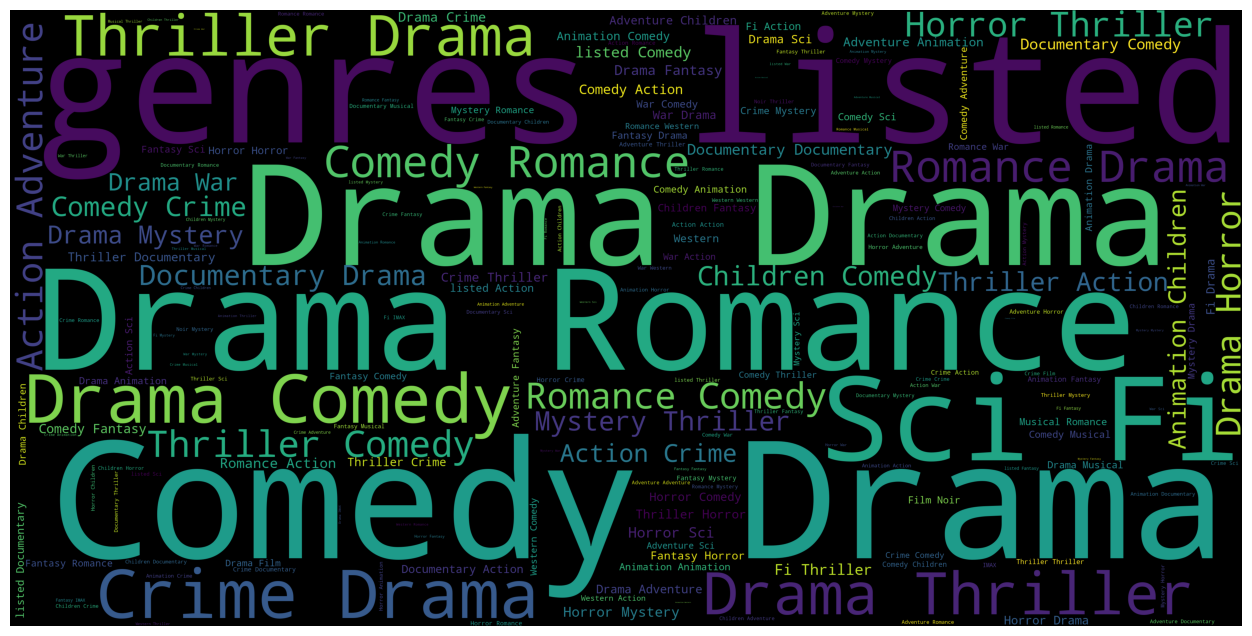

In [31]:
# Creating a wordcloud of the movie titles to view the most popular movie titles withtin the word cloud
movies['genres'] = movies['genres'].fillna("").astype('str')
tags_corpus = ' '.join(movies['genres'])
genres_wordcloud = WordCloud(stopwords=STOPWORDS, background_color='black', height=2000, width=4000, random_state= 42).generate(tags_corpus)

# Plotting the wordcloud
plt.figure(figsize=(16,8))
plt.imshow(genres_wordcloud)
plt.axis('off')
plt.show()

In [32]:
New = []  # empty list to append the movie Id and each genre of the movies
movie_genre = movies[["movieId", "title", "genres"]].copy()  # creating a copy of the DataFrame
movie_genre.loc[:, "genres"] = movie_genre.genres.apply(lambda x: x.split(','))  # splitting the genres of each movie by comma

for index, row in movie_genre.iterrows():
    for genre in row.genres:
        New.append([getattr(row, "movieId"), genre])

# Creating a DataFrame using the New list
Movie_genres = pd.DataFrame(New, columns=["movieId", "genres"])


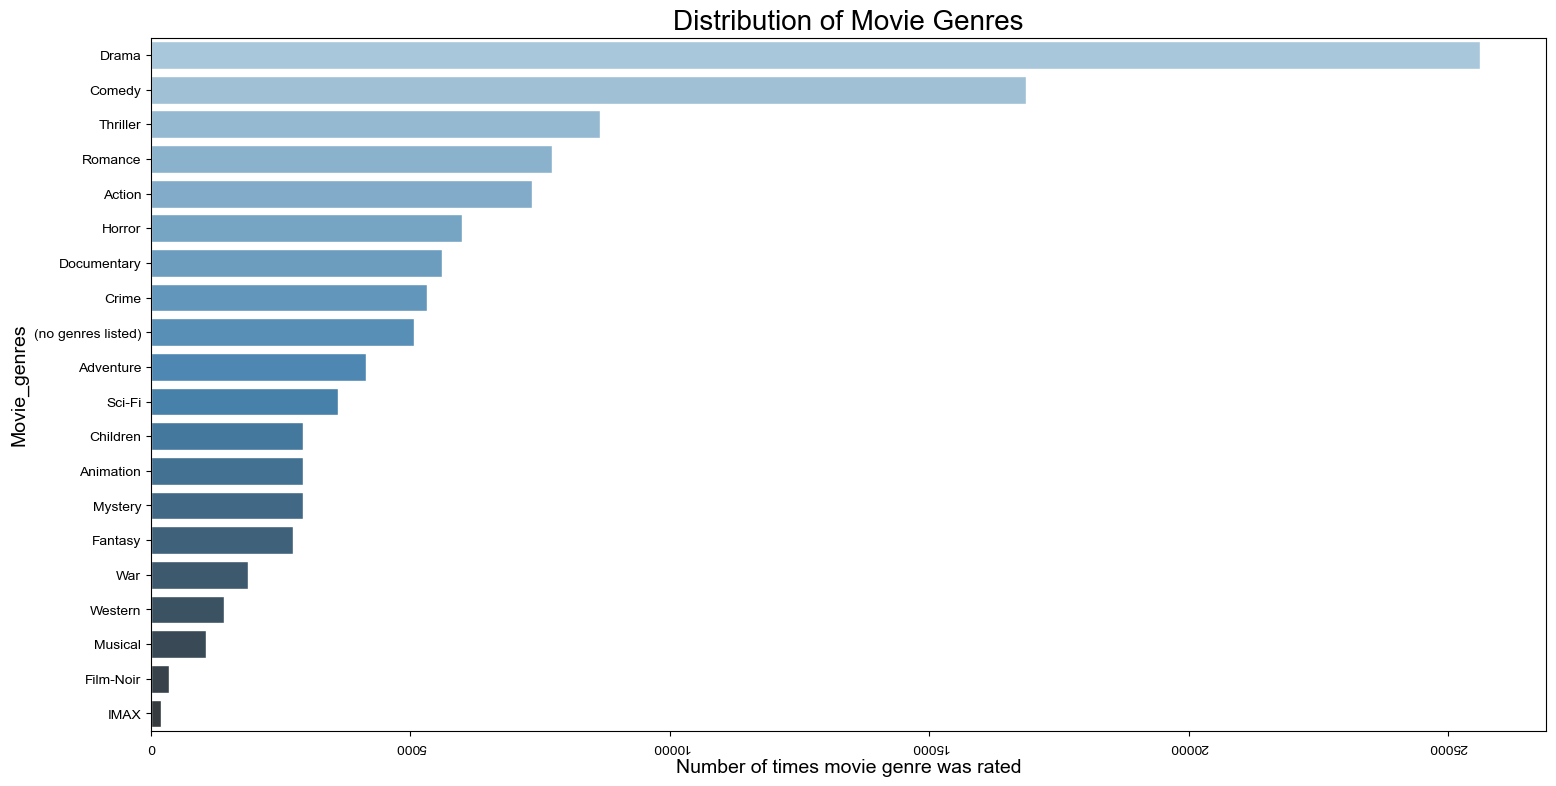

In [33]:
fig, ax = plt.subplots(figsize=(18, 9))# creating Subplot for visuals and indicating the size
sns.set(font_scale=1.1) # scales of the font
sns.countplot(y='genres' ,data=Movie_genres, order= Movie_genres['genres'].value_counts().index, palette="Blues_d") #Genrating visual using count plot 
plt.xticks(rotation=180)
plt.xlabel('Number of times movie genre was rated', fontsize=14)
plt.ylabel('Movie_genres', size=14)
plt.title('Distribution of Movie Genres', size=20)
plt.show()

From the visual above , This shows that users tend to rate Movie that are purely drama in nature, followed by comedy while they least rate movies with Imax genres. Therefore there is an high chance that a user would like a movie which is pure drama drama compared to musical movies.

In [34]:
# Assuming you have a 'ratings' DataFrame containing movie ratings

# Perform an inner merge on 'movieId'
merged_data = pd.merge(Movie_genres, df_rating, on='movieId', how='inner')

# Select the desired columns in the merged DataFrame
desired_columns = ['movieId', 'genres', 'rating']
result = merged_data[desired_columns]


In [35]:
result.head()

,movieId,genres,rating
0,1,Adventure,5.0
1,1,Adventure,5.0
2,1,Adventure,3.0
3,1,Adventure,4.0
4,1,Adventure,5.0


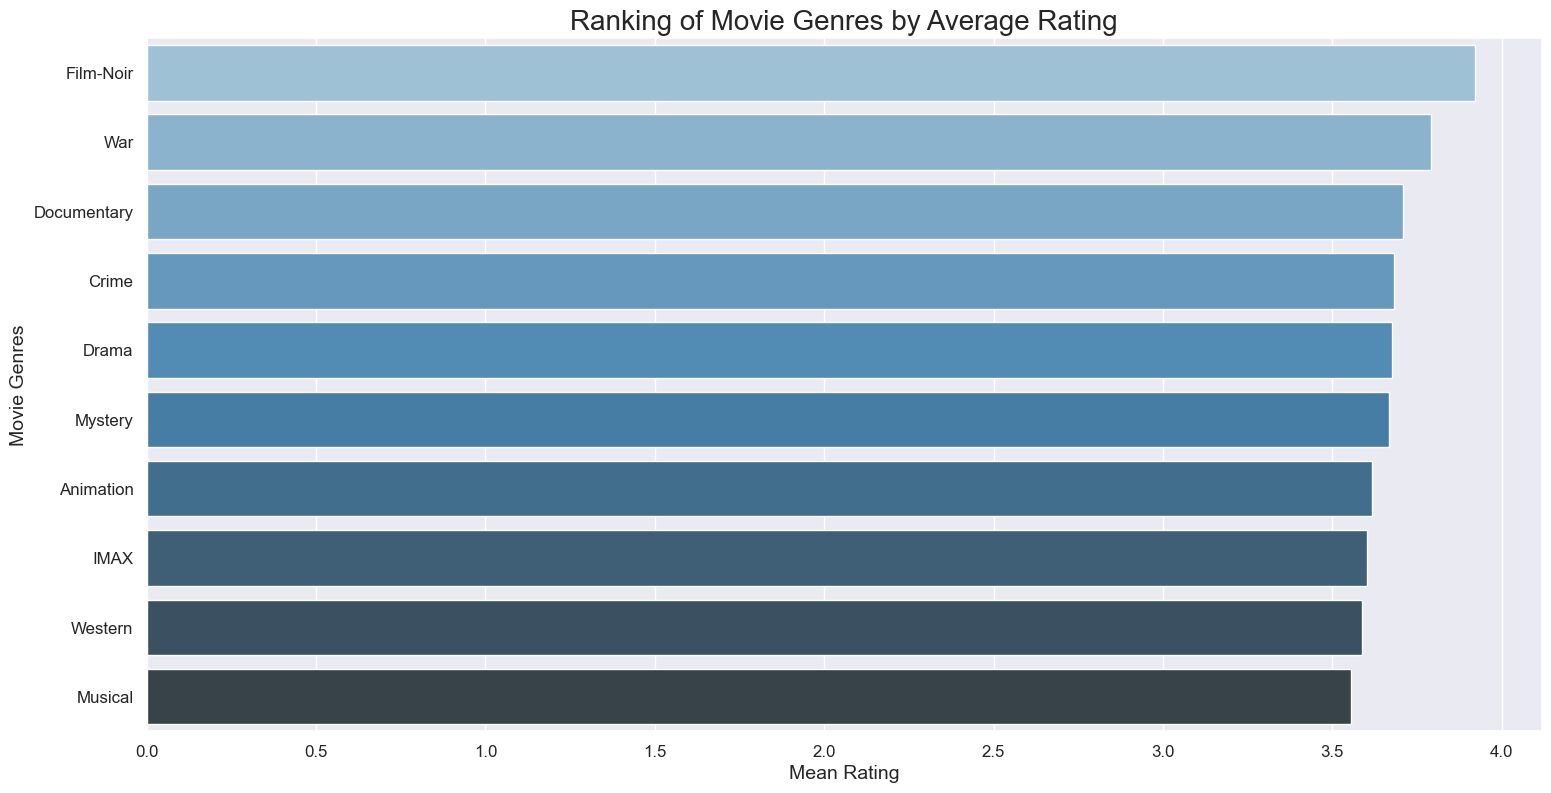

In [36]:
# Calculate the mean rating for each genre
mean_ratings = result.groupby('genres')['rating'].mean().sort_values(ascending=False).head(10)

# Create the bar graph
fig, ax = plt.subplots(figsize=(18, 9))
sns.set(font_scale=1.1)
sns.barplot(x=mean_ratings.values, y=mean_ratings.index, palette="Blues_d")

# Customize the graph
plt.xlabel('Mean Rating', fontsize=14)
plt.ylabel('Movie Genres', fontsize=14)
plt.title('Ranking of Movie Genres by Average Rating', fontsize=20)
plt.show()


**Observation**

* It is true that Film-Noir rank the first in terms of best genre but let us recall that film also ranked one of the lowest count hence we cannot categorically state that film-noir is the best genre.

* The best genre are War, Documentary, Crime and Drama.

In [37]:
result[result["genres"]=="(no genres listed)"]

,movieId,genres,rating
24489554,83773,(no genres listed),0.5
24489555,83773,(no genres listed),3.0
24513381,84768,(no genres listed),3.0
24614876,86493,(no genres listed),1.0
24648109,87061,(no genres listed),4.5
...,...,...,...
27120014,208943,(no genres listed),2.0
27120015,208973,(no genres listed),3.5
27120027,209063,(no genres listed),4.0
27120028,209067,(no genres listed),2.5


**Observation**

* There are over 10,651 movies that do nt have genre.

##### Movie production per year and how people rate movies per year

In [38]:
All_movie = movies[["movieId","title"]].copy()  # creating a copy of the DataFrame
All_movie.loc[:, "year"] = movies['title'].str[-5:-1]  # extracting the year

Movies_prod = All_movie['year'].value_counts()[0:75].sort_index().to_frame().reset_index()  # counting numbers of movies produced per year and sorting it in ascending order
Movies_prod = Movies_prod.rename(columns={'index': "year", 'year': "movies_prod"})  # renaming the columns


In [39]:
# Quick view of movies produced per year
Movies_prod.head()

,year,movies_prod
0,1937,234
1,1942,257
2,1947,232
3,1948,244
4,1949,265


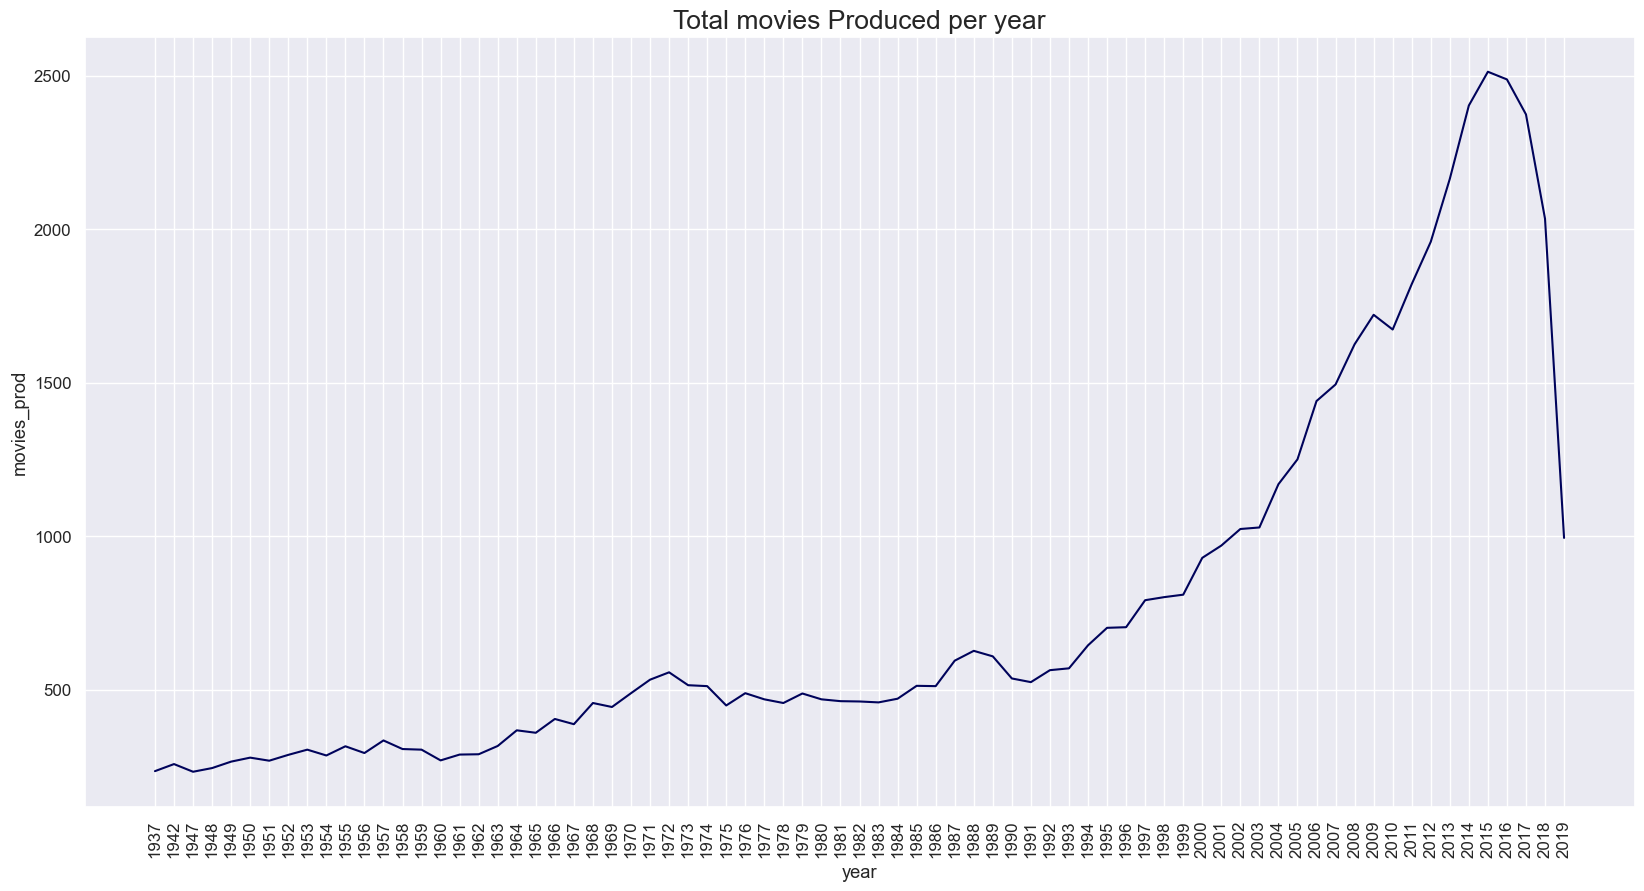

In [40]:
#Plotting total amount of movies released in each year using a count plot.
figure= plt.subplots(figsize=(20, 10))
axes=sns.lineplot(x="year",y= "movies_prod", data= Movies_prod, color= "#00035b" )
axes.set_title('Total movies Produced per year',fontsize=19)
plt.xticks(rotation=90)
plt.show()

Based on the time series analyis presented above, it is evident that there has been a significant increase in movie production after 2000 compared to earlier years, where the number of movies produced was relatively low. This surge in production can potentially be attributed to advancements in technology. However, it is worth noting that the year 2019 appears to be an anomaly with a relatively lower turnout. Further investigation is necessary to gain a deeper understanding of the factors influencing this decline in movie production during that particular year. (Could it be the Covid19 pandemic 🤔, well... i doubt that because Covid really manfested in 2020).

2015 was the highest production of movies.

In [41]:
df_rating['title'] = df_rating.merge(movies, on=['movieId'], how='left')['title']
df_rating.head()

,userId,movieId,rating,timestamp,title
0,5163,57669,4.0,1518349992,In Bruges (2008)
1,106343,5,4.5,1206238739,Father of the Bride Part II (1995)
2,146790,5459,5.0,1076215539,Men in Black II (a.k.a. MIIB) (a.k.a. MIB 2) (...
3,106362,32296,2.0,1423042565,Miss Congeniality 2: Armed and Fabulous (2005)
4,9041,366,3.0,833375837,Wes Craven's New Nightmare (Nightmare on Elm S...


In [42]:
# Exracting the year movies was created from the titles 
# Create a copy of the movie_ratings dataframe
movie_rated = df_rating.copy()
# Extract release year from movie titles
movie_rated['release_year']=movie_rated['title'].str[-5:-1] #extracting released year
movies_rated = movie_rated['release_year'].value_counts()[0:75].sort_index().to_frame().reset_index()
movies_rated= movies_rated.rename(columns= {'index': "year", 'release_year': "Number_of_rate"})

In [43]:
movie_rated[(movie_rated["release_year"]== '2019') ]

,userId,movieId,rating,timestamp,title,release_year
957,15044,202575,3.5,1560752198,Late Night (2019),2019
1614,122569,199237,4.0,1570040592,Paddleton (2019),2019
2732,99575,197203,3.0,1554677320,Triple Frontier (2019),2019
3290,79382,199223,2.5,1558850078,Pet Sematary (2019),2019
6018,22349,204542,3.5,1568130659,It: Chapter Two (2019),2019
...,...,...,...,...,...,...
9998327,8461,201588,4.0,1573053055,Toy Story 4 (2019),2019
9998796,42297,200824,3.5,1570488554,The Secret Life of Pets 2 (2019),2019
9999201,61059,122914,3.5,1563158406,Avengers: Infinity War - Part II (2019),2019
9999759,146987,200820,2.0,1564897545,Godzilla: King of the Monsters (2019),2019


In [44]:
movie_rated[(movie_rated["release_year"]== '2020') ]

,userId,movieId,rating,timestamp,title,release_year


In [45]:
movie_rated[(movie_rated["release_year"]== '2021') ]

,userId,movieId,rating,timestamp,title,release_year


Since there are no movies collection for  in 2020 and 2021, it is possible the we do not have every collection for 2019 hence the low 2019 Movie counts.

In [46]:
movie_rated['release_year'].value_counts()

1995    598371
1994    521621
1999    450380
1996    444231
2000    386359
         ...  
Chao         1
ort          1
skog         1
utto         1
 Lad         1
Name: release_year, Length: 406, dtype: int64

In [47]:
movies_rated.head()

,year,Number_of_rate
0,1937,11120
1,1939,23356
2,1940,22906
3,1941,20919
4,1942,18916


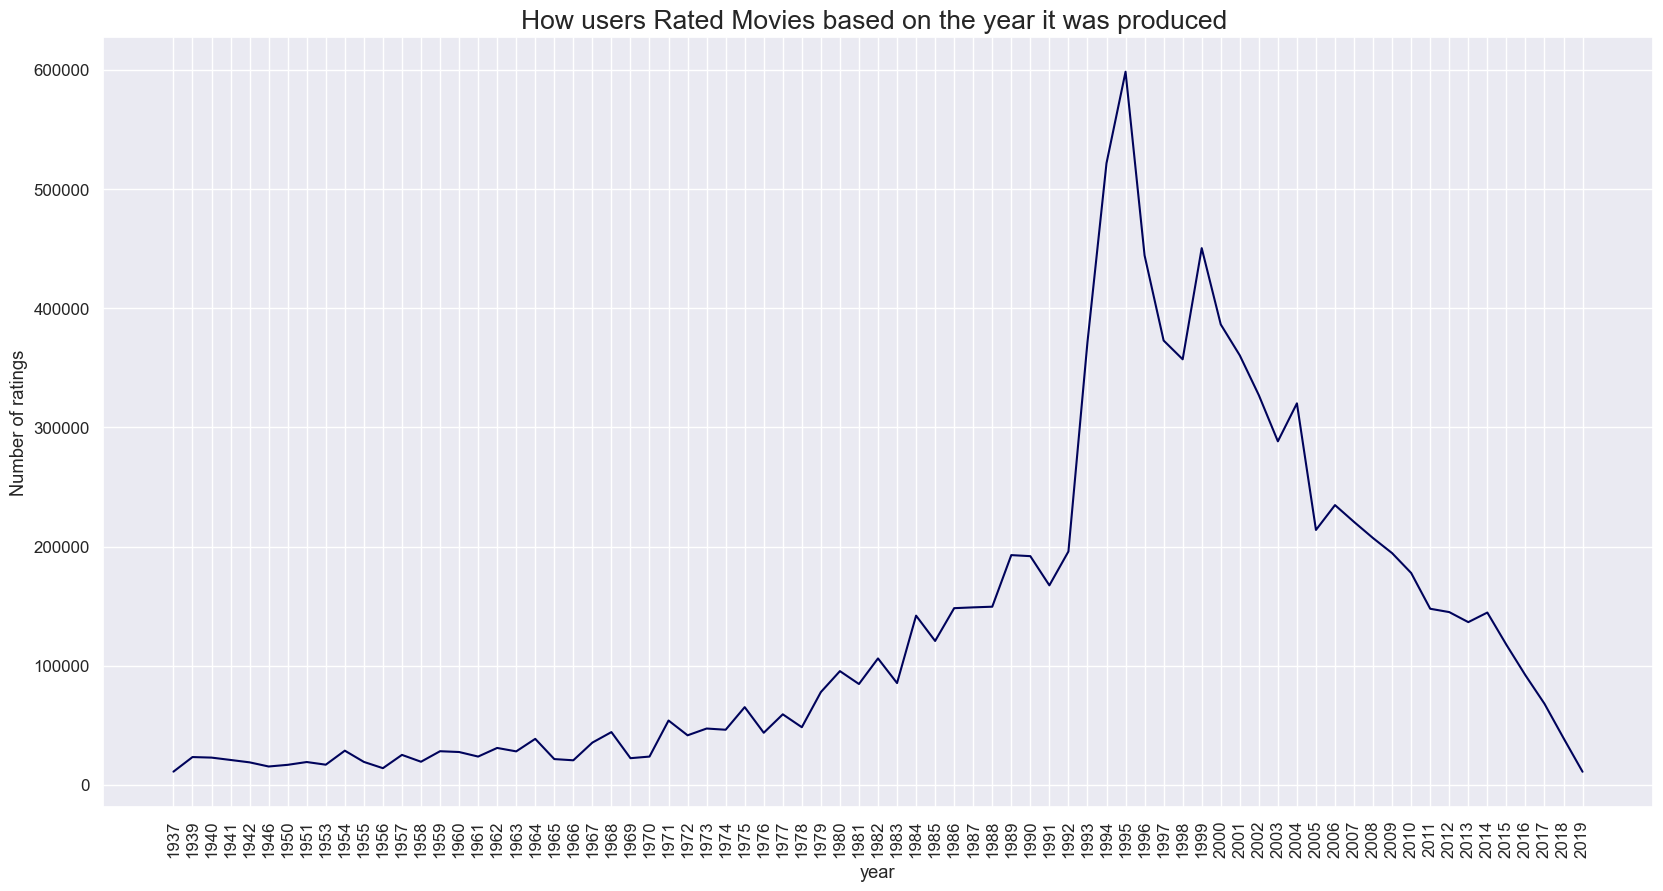

Total Number of Rate since 1900  10000038


In [48]:
#Plotting total amount of movies released in each year using a count plot.
figure= plt.subplots(figsize=(20, 10))
axes=sns.lineplot(x="year",y= "Number_of_rate", data= movies_rated,color= "#00035b"  )
axes.set_title('How users Rated Movies based on the year it was produced ',fontsize=19)
plt.xticks(rotation=90)
plt.ylabel("Number of ratings")
plt.show()
print( "Total Number of Rate since 1900 ", len(df_rating))

The the time series graph above, we can see that 1995 has the hightest user rating.  Could it be that alot of popular movies was produced that year, well i was not born then 🤷🏽‍♂, come with me, lets dig further.

In [49]:
b =movie_rated[(movie_rated["release_year"]== "1995") & (movie_rated["rating"]== 5)]
b.head()

,userId,movieId,rating,timestamp,title,release_year
119,158849,1,5.0,994716786,Toy Story (1995),1995
154,97203,1,5.0,942683155,Toy Story (1995),1995
219,144638,6,5.0,944928353,Heat (1995),1995
473,112595,333,5.0,841557465,Tommy Boy (1995),1995
651,76064,110,5.0,854262666,Braveheart (1995),1995


In [50]:
c= movie_rated[(movie_rated["release_year"]== "1995") & (movie_rated["rating"]< 5)]
c.head()

,userId,movieId,rating,timestamp,title,release_year
1,106343,5,4.5,1206238739,Father of the Bride Part II (1995),1995
22,57239,150,4.0,997154778,Apollo 13 (1995),1995
65,22508,208,1.0,973727227,Waterworld (1995),1995
71,64344,50,3.5,1297529216,"Usual Suspects, The (1995)",1995
73,68397,165,3.5,1140159512,Die Hard: With a Vengeance (1995),1995


In [51]:
round((b.shape[0]/c.shape[0]) * 100,2)

18.15

After investigating and exploring the movie dataset, we confirmed that a lot of top rated popular movie was produced during this year compared to other years. We talking about 18%.

####  Summary of Exploratory Data Analysis
After performing Exploratory data analysis of the data sets provided, we were able to find out that:


* Users generally rate movies in whole number formats like 4.0, 3.0, 2.0 rather than their decimal format like 4.5, 3.5, 2.5 etc

* Average rating of 3.55 and a modal rating of 4.0.

* A user selected at random will most likely rate a movie between 3.0 and 5.0 as most of the ratings are distributed within this range.

* The Top 10 most rated movies are produced in the 90s

* The best rated movies share common genre, these movies are between War, Documentary, Crime and Drama.

* Year of production can play a part in predicting the rating of a movie

* Genre as a stand alonde feature does not have much effect on the rating of a movie

* 2015 recorded the highest amount of movies production

* Movies produced in 1995 has the highest cumulated rating

* Popular movie genres are drama, comedy , triller.

* Most commonly used tags are  Sci Fi, comedy, twist, nudity, Oscar best, topless, Morgan Freeman.

* Does not contain any movie created in 2020 , therefore this dataset was collect in 2019.

* 10,651 movies that do not have genre.


<a id="5"></a>
## 5. Feature Engineering
<a href=#cont>Back to Table of Contents</a>

This project considers building a recommender off the movie genre, the director and the plot keyword feature. 

####  Selecting the Required Features

The movie genre is available in the movies dataset, the director and plot keywords features are in the imdb_data dataset. Hence, there is a need to merge both datasets and extract the required features. 

In [96]:
# Extract movieId, title_cast, director and plot_keywords from imdb_df
imdb_df = imdb_df[['movieId', 'director', 'plot_keywords']]


# merge meta dataset to movies dataset to produce our train dataset
df_train = movies.merge(imdb_df, on='movieId', how='left')
df_train.head()

,movieId,title,genres,director,plot_keywords
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,John Lasseter,toy|rivalry|cowboy|cgi animation
1,2,Jumanji (1995),Adventure|Children|Fantasy,Jonathan Hensleigh,board game|adventurer|fight|game
2,3,Grumpier Old Men (1995),Comedy|Romance,Mark Steven Johnson,boat|lake|neighbor|rivalry
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,Terry McMillan,black american|husband wife relationship|betra...
4,5,Father of the Bride Part II (1995),Comedy,Albert Hackett,fatherhood|doberman|dog|mansion



**Cleaning the Selected features**

The genres and plot keywords feature contains genres and keywords seperated by the '|' character. There is a need to replace the seperator character with a space. On the director feature, there is a need to remove the space between the director name and surname; this is so that the model will not percieve any similarity between Albert Johnson and Albert Robert. They are totally different persons. And lastly, merging the features together and changing them to all lowercasing.

In [97]:
# handle missing data
df_train.fillna(' ', inplace=True)

# replacing "|" and "(no genres listed)" with ' ' in genre
df_train['genres'] = df_train['genres'].apply(lambda x: x.replace("|" , ' ')
                                       .replace("(no genres listed)", ' '))

# replacing " " with ' ' in director
df_train['director'] = df_train['director'].apply(lambda x: ((x+'|'))
                                            .replace(" ", '')
                                            .replace("|", " "))

# replace "|" with ' ' in plot_keywords
df_train['plot_keywords'] = df_train['plot_keywords'].apply(lambda x: x.replace("|", " "))

# Merge the genres, plot_keywords and director names as our major predictors
df_train_string = df_train['genres'] + " " + df_train['director'] + " " + df_train['plot_keywords']

# change to lower case
df_train_string.apply(str.lower)

0        adventure animation children comedy fantasy jo...
1        adventure children fantasy jonathanhensleigh  ...
2        comedy romance markstevenjohnson  boat lake ne...
3        comedy drama romance terrymcmillan  black amer...
4        comedy alberthackett  fatherhood doberman dog ...
                               ...                        
62418                                            drama    
62419                                      documentary    
62420                                     comedy drama    
62421                                                     
62422                           action adventure drama    
Length: 62423, dtype: object

**Vectorization**

We now need a mechanism to convert these textual features into a format which enables us to compute their relative similarities to one another.
This will allow us to translate our string-based collection of tags and authors into numerical vectors

For this project we define a vectorizer with the following tuning
- analyser = 'word'
- ngram_range = (1, 1)
- max_df = 0.3
- min_df = 20
- stop_words = 'english'

In [98]:
vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 1), min_df=10, max_df=0.5, stop_words='english')
features = vectorizer.fit_transform(df_train_string)

features.shape

(62423, 1581)

**Recommending**

This section contains functions for making movie recommendation for a user using the vectorised features from the previous section. The section contains four functions 

**Retrieving Top N Movies Rated by a User**

To perform content based filtering, there is a need to retrieve all movies rated by the user under focus sorted by the rating the user ascribe to them in descending order. 

In [99]:
#function to collect all movies rated by a particular user

def all_user_rated_movies(userId, n):
    rated_movies = df_rating[df_rating['userId'] == userId]
    rated_sorted =  rated_movies.sort_values(by='rating', ascending=False)
    return rated_sorted['movieId'].iloc[:n]

**Retrieving All Unseen Movies by a User**

Similarly, there is also a need to retrieve all movies previously unseen by a user from which we can make recommendation from to avoid recommending movies which has previously been seen by a user.

In [100]:
def all_unseen_movies(userId):
    unseen_movies = df_rating[df_rating['userId'] != userId]['movieId']
    return movies[movies['movieId'].isin(unseen_movies)].index

**Recommending Top N Unseen Movies by user**

Using the cosine similarity, the top N similar movies to each top rated movies by the user is recommended for the user.

In [101]:
# Recommend the Top N movies for each top rated movie by a user

def recommend(movie_df, userId, n=10):
    top_rated_movies_id = all_user_rated_movies(userId, int(n/2))
    unseen_movies = all_unseen_movies(userId)
    similarity_list = []
    
    for movieId in list(top_rated_movies_id):
        movie_index = movie_df[movie_df['movieId'] == movieId].index[0]
        sim_matrix = cosine_similarity(features[movie_index], features[unseen_movies])[0]
        
        for i in range(2):
            similarity_list.append(np.argmax(sim_matrix))
            sim_matrix[np.argmax(sim_matrix)] = 0
        
    return df_train.iloc[similarity_list]

Using the recommend function to recommend 15 movies for user with userId 600

In [79]:
recommend(movies, 600, 15)

,movieId,title,genres,director,plot_keywords
703,718,"Visitors, The (Visiteurs, Les) (1993)",Comedy Fantasy Sci-Fi,ChristianClavier,time travel year 1123 12th century 20th century
8150,8865,Sky Captain and the World of Tomorrow (2004),Action Adventure Sci-Fi,KerryConran,steampunk reporter dieselpunk mechanical monster
262,265,Like Water for Chocolate (Como agua para choco...,Drama Fantasy Romance,LauraEsquivel,mexico food marriage love
21113,109153,Ray Harryhausen: Special Effects Titan (2011),Documentary,GillesPenso,film producer giant gorilla animator visual ef...
452,457,"Fugitive, The (1993)",Thriller,JebStuart,one armed man on the run u.s. marshal surgeon
13388,69159,Jimmy and Judy (2006),Crime Drama Thriller,JonathanSchroder,watching tv character names as title forenames...
103,105,"Bridges of Madison County, The (1995)",Drama Romance,MerylStreep,bridge love farm photographer
9982,33669,"Sisterhood of the Traveling Pants, The (2005)",Adventure Comedy Drama,AnnBrashares,pantyhose friendship sisterhood female friendship
324,329,Star Trek: Generations (1994),Adventure Drama Sci-Fi,GeneRoddenberry,female empath half human half alien empath hum...
17040,89616,My Little Business (Ma petite entreprise) (1999),Comedy Drama,PierreJolivet,insurance fraud


In [80]:
recommend(movies, 25, 15)

,movieId,title,genres,director,plot_keywords
585,593,"Silence of the Lambs, The (1991)",Crime Horror Thriller,ThomasHarris,serial killer psycho thriller bad guy wins stu...
4284,4389,Lost and Delirious (2001),Drama,SusanSwan,lesbian girls' boarding school teenage sexuali...
149,151,Rob Roy (1995),Action Drama Romance War,AlanSharp,scotland highlands 18th century flintlock pistol
9871,33051,Skin Game (1971),Comedy Romance Western,,
530,535,Short Cuts (1993),Drama,RaymondCarver,waitress destruction of property female full r...
15865,83603,Fern flowers (Fleur de fougère) (1949),Animation,WladyslawStarewicz,
51,52,Mighty Aphrodite (1995),Comedy Drama Romance,WoodyAllen,new york city talking about sex husband wife r...
2482,2573,Tango (1998),Drama Musical,CarlosSaura,female nudity topless female nudity female ful...
292,296,Pulp Fiction (1994),Comedy Crime Drama Thriller,QuentinTarantino,nonlinear timeline overdose drug overdose bondage
24262,121077,Meet Boston Blackie (1941),Crime Drama,,


**Reducing the Dataset Dimension**

Our initial ratings dataset which plays a pivotal role in the training of this model contains a little above 10 million records. This will constitute a speed inefficiency during training. To reduce the dimension of our training dataset, we filter out movies with low ratings and users who have only rated few movies. 

In [102]:
def filter_low_rated_movies(df, min_no_rating):
    movies_per_rating = dict(Counter(df.movieId))
    required_movies = []
    
    for key, value in movies_per_rating.items():
        if value > min_no_rating:
            required_movies.append(key)
        
    return df[df['movieId'].isin(required_movies)]

In [103]:
df_filtered = filter_low_rated_movies(df_rating, 2500)

print("The old dataset has {} shape".format(df_rating.shape))
print("The dataset with low ratings removed has {} shape".format(df_filtered.shape))

The old dataset has (10000038, 4) shape
The dataset with low ratings removed has (6035923, 4) shape


**Filtering Users who have rated below Benchmark number of ratings**

In [104]:
def filter_low_rating_users(df, min_no_rating):
    users_per_rating = dict(Counter(df.userId))
    required_users = []
    
    for key, value in users_per_rating.items():
        if value > min_no_rating:
            required_users.append(key)
        
    return df[df['userId'].isin(required_users)]

In [105]:
df_cleaned = filter_low_rating_users(df_filtered, 250)

print("The dataset with low rating users removed has {} shape".format(df_cleaned.shape))

The dataset with low rating users removed has (190361, 4) shape


<a id="6"></a>
## 6. Modelling
<a href=#cont>Back to Table of Contents</a>

In [106]:
# Tune the surprise reader prediction scale
reader = Reader(rating_scale=(1, 5))

# load the training dataset with the surprise dataset class
data = Dataset.load_from_df(df_cleaned[['userId', 'movieId', 'rating']], reader)

The surprise library provides a range of models which can be used to make predictions. In this section, we select few distinct models and benchmark their performance

In [24]:
benchmark = []
# Iterate over all algorithms

algorithms = [SVD(), NMF(), NormalPredictor(), CoClustering()]

print ("Attempting: ", str(algorithms), '\n\n\n')

for algorithm in algorithms:
    print("Starting: " ,str(algorithm))
    # Perform cross validation
    results = cross_validate(algorithm, data, measures=['RMSE'], cv=3, verbose=False)
    
    # Get results & append algorithm name
    tmp = pd.DataFrame.from_dict(results).mean(axis=0)
    tmp = tmp.append(pd.Series([str(algorithm).split(' ')[0].split('.')[-1]], index=['Algorithm']))
    benchmark.append(tmp)
    print("Done: " ,str(algorithm), "\n\n")

print ('\n\tDONE\n')

Attempting:  [<surprise.prediction_algorithms.matrix_factorization.SVD object at 0x7eea4d15f340>, <surprise.prediction_algorithms.matrix_factorization.NMF object at 0x7eea4d15f670>, <surprise.prediction_algorithms.random_pred.NormalPredictor object at 0x7eea4d15eec0>, <surprise.prediction_algorithms.co_clustering.CoClustering object at 0x7eea4d15c310>] 



Starting:  <surprise.prediction_algorithms.matrix_factorization.SVD object at 0x7eea4d15f340>
Done:  <surprise.prediction_algorithms.matrix_factorization.SVD object at 0x7eea4d15f340> 


Starting:  <surprise.prediction_algorithms.matrix_factorization.NMF object at 0x7eea4d15f670>
Done:  <surprise.prediction_algorithms.matrix_factorization.NMF object at 0x7eea4d15f670> 


Starting:  <surprise.prediction_algorithms.random_pred.NormalPredictor object at 0x7eea4d15eec0>
Done:  <surprise.prediction_algorithms.random_pred.NormalPredictor object at 0x7eea4d15eec0> 


Starting:  <surprise.prediction_algorithms.co_clustering.CoClustering obje

<a id="7"></a>
## 7. Model Evaluation
<a href=#cont>Back to Table of Contents</a>

In [26]:
surprise_results = pd.DataFrame(benchmark).set_index('Algorithm').sort_values('test_rmse')
surprise_results

,test_rmse,fit_time,test_time
Algorithm,,,
SVD,0.777303,2.370970,0.844286
NMF,0.794962,4.081218,0.660163
CoClustering,0.805409,4.089370,0.694392
NormalPredictor,1.367007,0.294671,0.605192


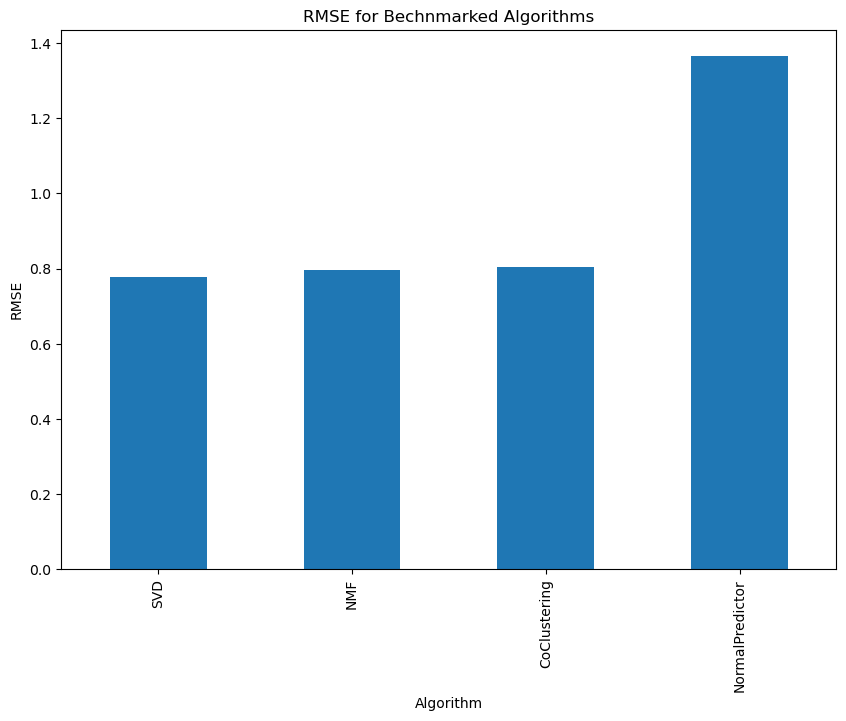

In [27]:
# visualising the result on a bar chart
surprise_results['test_rmse'].plot(kind='bar', figsize=(10,7))
plt.ylabel("RMSE")
plt.title("RMSE for Bechnmarked Algorithms")
plt.show()

In [107]:
# Hyperparameter tuning variable
params = {
    "n_epochs": 20,
    "lr_all": 0.005,
    "reg_all": 0.02
}

# Configurable minimum number of movie and users ratings
min_no_movie_rating = 2500
min_no_user_rating = 250

# Filter the training set with the configuration
training_set = filter_low_rated_movies(df_rating, min_no_movie_rating)
training_set = filter_low_rating_users(training_set, min_no_user_rating)

# load the dataset
data = Dataset.load_from_df(training_set[['userId', 'movieId', 'rating']], reader)
print(training_set.shape)

# build a full trainset from the dataset
trainset = data.build_full_trainset()

algo = SVD(n_epochs = params['n_epochs'], lr_all = params['lr_all'], reg_all = params['reg_all'])

algo.fit(trainset)

(190361, 4)


<a id="8"></a>
## 8. Model Explanation
<a href=#cont>Back to Table of Contents</a>

From the benchmark in the previous section, the best performing model is the SVDpp, which is a variant of the SVD model. Although, its performance does not come without a limitation. It is the slowest of all the models by a wide marging. Its training and testing time is very high and might cause a bottle for our usecase. The use case is a movie recommendation system; there will be expectation of trafic upon its deployment. Hence, for this project, its variant SVD is considered.

<a id="9"></a>
## 9. Conclusion
<a href=#cont>Back to Table of Contents</a>

****<a id="10"></a>
## 10. Making Kaggle Submission
<a href=#cont>Back to Table of Contents</a>

In [ ]:
# function to predict a single rating
def predict_each(row, model):
    row['id'] = str(row['userId']) + '_' + str(row['movieId'])
    row['rating'] = round(model.predict(row['userId'], row['movieId'], verbose=False).est, 2)
    return row[['id', 'rating']]

# function to predict all the entries in a dataframe
def predict(df, model):
    data = df.apply(predict_each, model=model, axis='columns')
    return data

In [ ]:
# adjust this number for more or fewer predictions
number_of_predictions = 5000018

# read the test dataset
test = pd.read_csv(r'/kaggle/input/TeamBM3UnsupervisedNotebook/test.csv')

# Make the required number of predictions
df_prediction = predict(test[:number_of_predictions], algo)

df_prediction

In [ ]:
df_prediction.to_csv("submission_3.csv", index=False)

<a id="11"></a>
## 11. Pickle Files for Streamlit
<a href=#cont>Back to Table of Contents</a>

<a id="12"></a>
## 12. Log Model Features To Comet_ml
<a href=#cont>Back to Table of Contents</a>

<a id="13"></a>
## 13. References
<a href=#cont>Back to Table of Contents</a>